In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas

In [ ]:
from ucimlrepo import fetch_ucirepo 
  
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# print(breast_cancer_wisconsin_diagnostic.metadata) 
  
print(breast_cancer_wisconsin_diagnostic.variables) 

y["Diagnosis"] = y["Diagnosis"].map({"M": 1, "B": 0})


                  name     role         type demographic description units  \
0                   ID       ID  Categorical        None        None  None   
1            Diagnosis   Target  Categorical        None        None  None   
2              radius1  Feature   Continuous        None        None  None   
3             texture1  Feature   Continuous        None        None  None   
4           perimeter1  Feature   Continuous        None        None  None   
5                area1  Feature   Continuous        None        None  None   
6          smoothness1  Feature   Continuous        None        None  None   
7         compactness1  Feature   Continuous        None        None  None   
8           concavity1  Feature   Continuous        None        None  None   
9      concave_points1  Feature   Continuous        None        None  None   
10           symmetry1  Feature   Continuous        None        None  None   
11  fractal_dimension1  Feature   Continuous        None        

In [3]:
X = np.array(X)
y = np.array(y)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

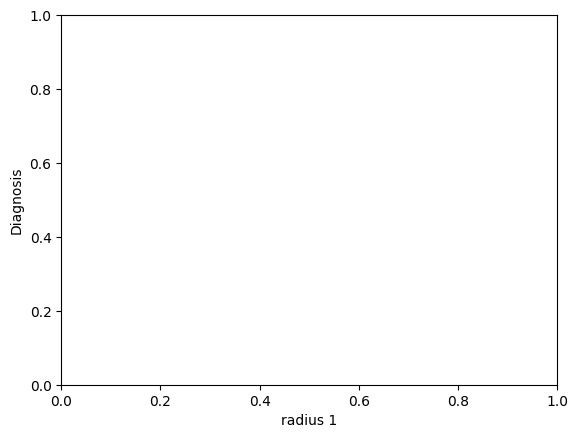

In [4]:
plt.xlabel("radius 1")
plt.ylabel("Diagnosis")
plt.plot(X["radius1"], y["Diagnosis"], 'o')

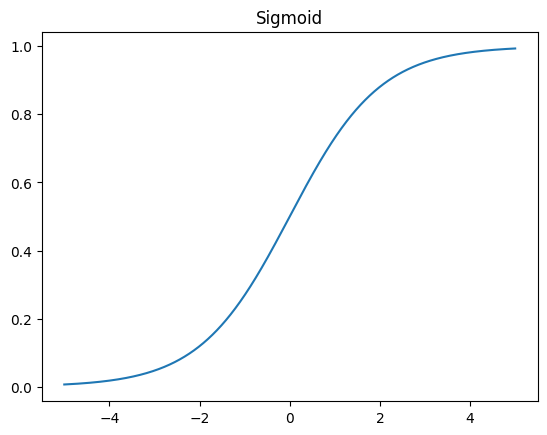

In [5]:
# Sigmoid Activation Function

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x_sigmoid = np.linspace(-5, 5, 10000)
y_sigmoid = sigmoid(x_sigmoid)

plt.title("Sigmoid")
plt.plot(x_sigmoid, y_sigmoid)

In [82]:
class Logistic_Regression():
    def __init__(self, nfeature, learning_rate):
        self.nfeature = nfeature
        self.w = np.zeros((nfeature))
        self.b = 0
        self.a = learning_rate
    
    def pred(self, X):
        return sigmoid(X @ self.w + self.b)

    def loss(self, X, y):
        """
        We use cross-entropy loss function here.
        """
        y_pred = self.pred(X)
        return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
    
    def train(self, X, y):
        y_pred = self.pred(X)
        dw = X.T @ (y_pred - y) / y_pred.shape[0]
        db = np.mean(y_pred - y)
        self.w -= self.a * dw
        self.b -= self.a * db

In [83]:
# Standardization
X_std = (X - X.mean(axis=0)) / X.std()
y = y.reshape(-1)

In [94]:
learning_rate = 0.01
epoch = 80000

model = Logistic_Regression(X_std.shape[1], learning_rate)

epochs = np.linspace(1, epoch, epoch)
losses = np.zeros_like(epochs)

In [95]:
for i in range(epoch):
    model.train(X_std, y)
    losses[i] = model.loss(X_std, y)

/var/folders/ct/0ly4pxps72j3qzzlrkkqymgw0000gn/T/ipykernel_21878/623746913.py:16: RuntimeWarning: divide by zero encountered in log
  return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
/var/folders/ct/0ly4pxps72j3qzzlrkkqymgw0000gn/T/ipykernel_21878/623746913.py:16: RuntimeWarning: invalid value encountered in multiply
  return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))


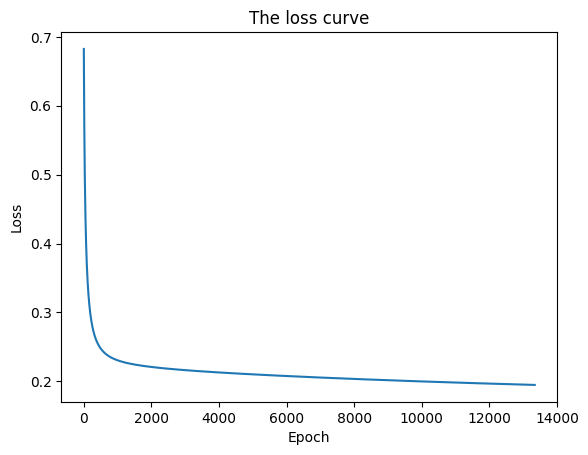

In [96]:
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("The loss curve")

plt.plot(epochs, losses)

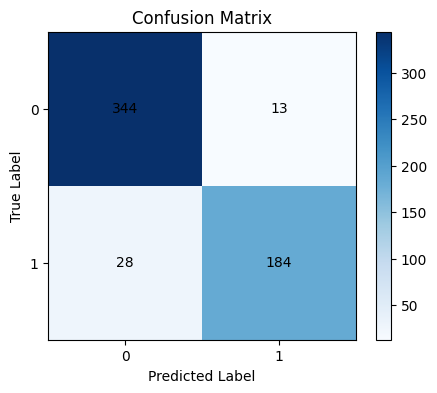

In [98]:
y_prob = model.pred(X_std)
y_pred = (y_prob >= 0.5).astype(int)
y_true = y.reshape(-1)

tp = np.sum((y_true == 1) & (y_pred == 1))
tn = np.sum((y_true == 0) & (y_pred == 0))
fp = np.sum((y_true == 0) & (y_pred == 1))
fn = np.sum((y_true == 1) & (y_pred == 0))

cm = np.array([
    [tn, fp],
    [fn, tp]
])

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

labels = ["0", "1"]
plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.show()